# Exploring the QoMEX 2026 Results

This notebook explores the results obtained on the Kodak dataset in the paper 🌐⁠⁠ [*Estimating SSIM from MSE for DCT-Based Compressed Images via Modeling Local Error Statistics*](https://github.com/luctrudeau/approxSSIMate/blob/main/docs/qomex2026-approxssimate-poster.pdf), presented at QoMEX 2026.

It walks through the main steps used to estimate SSIM from MSE with ApproxSSIMate and compare the estimates with reference SSIM values.

In [1]:
# To install approxSSIMate, run the following command (just uncomment and run in this cell)
# %pip install -e ..
from approxssimate import compute_k

import io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm
from urllib import request


# Step 1: Fetch the Kodak images

For each image in the Kodak dataset, we compute a source-dependent coefficient $k$ using the `compute_k()` function.

The paper presents two variants:

1. `k_std`, based on the local standard deviation
2. `k_var`, based on the local variance raised to the power $\beta = 0.46$

Each coefficient is computed only once per source image and then reused to approximate SSIM at every JPEG quality level.

In [2]:
img_indices = list(range(1, 25))

def fetch_kodak(index=23, cache_dir="data"):
    """
    Download a Kodak image (1-24) if not already cached.
    Returns a numpy array (grayscale).
    """
    assert 1 <= index <= 24, "Kodak index must be between 1 and 24"
    
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    
    filename = f"kodim{index:02d}.png"
    filepath = cache_dir / filename
    
    if not filepath.exists():
        url = f"http://r0k.us/graphics/kodak/kodak/{filename}"
        request.urlretrieve(url, filepath)
    
    img = Image.open(filepath).convert("L")
    return np.array(img, dtype=np.float64)

reference_images = []

for i in tqdm(img_indices, desc="Fetching Kodak images"):
    img = fetch_kodak(i)
    k_std = compute_k(img)
    k_var = compute_k(img, beta=0.46) 
    reference_images.append((i, img, k_std, k_var))

Fetching Kodak images: 100%|██████████| 24/24 [00:00<00:00, 56.17it/s]


# Step 2: Apply JPEG compression and measure SSIM

The paper evaluates JPEG quality levels ranging from 25 to 95.

For each compressed rendition, we compute:

1. the reference SSIM value
2. the MSE, which ApproxSSIMate uses to estimate SSIM

In [3]:
jpeg_qualities = list(range(25, 99, 5))

def jpeg_compress(img, quality=75):
    buffer = io.BytesIO()

    img_u8 = np.asarray(img)
    if img_u8.dtype != np.uint8:
        img_u8 = np.clip(img_u8, 0, 255).astype(np.uint8)

    Image.fromarray(img_u8).save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert("L")

def mse(a, b):
    return np.mean(np.square(a - b))

compressed_images = []

for i, img, k_std, k_var in reference_images:
    for q in tqdm(jpeg_qualities, desc=f"Processing Kodak {i:02d}", unit="quality"):
        compressed_img = jpeg_compress(img, quality=q)
        compressed_array = np.array(compressed_img, dtype=np.float64)
        compressed_images.append((i, k_std, k_var, q, img, ssim(img, compressed_array, data_range=255.0), mse(img, compressed_array)))

Processing Kodak 24: 100%|██████████| 15/15 [00:00<00:00, 77.46quality/s]


# Step 3: Approximate SSIM

Using the coefficient $k$ computed from each source image and the MSE measured for each compressed rendition, we approximate SSIM as:

$$
\widehat{\mathrm{SSIM}} = 1 - k \cdot \mathrm{MSE}
$$

We compute one estimate using `k_std` and another using `k_var`.

In [4]:
approxSSIMate_results = []

for i, k_std, k_var, q, ref_img, ssim_val, mse_val in compressed_images:
    approxSSIMate_results.append({
        "i": i,
        "quality": q,
        "ssim": ssim_val,
        "approx_ssim_std": np.clip(1 - mse_val * k_std, 0, 1),
        "approx_ssim_var": np.clip(1 - mse_val * k_var, 0, 1)
    })

results = pd.DataFrame(approxSSIMate_results)
results.head()

,i,quality,ssim,approx_ssim_std,approx_ssim_var
0,1,25,0.842977,0.872509,0.864122
1,1,30,0.861339,0.888360,0.881016
2,1,35,0.875195,0.900401,0.893849
3,1,40,0.885985,0.909206,0.903233
4,1,45,0.895559,0.917277,0.911835


# Step 4: Plot the results

Finally, we average the reference and approximated SSIM values across the Kodak dataset for each JPEG quality level.

The resulting curves show how closely the two ApproxSSIMate variants track the reference SSIM values over the full quality range.

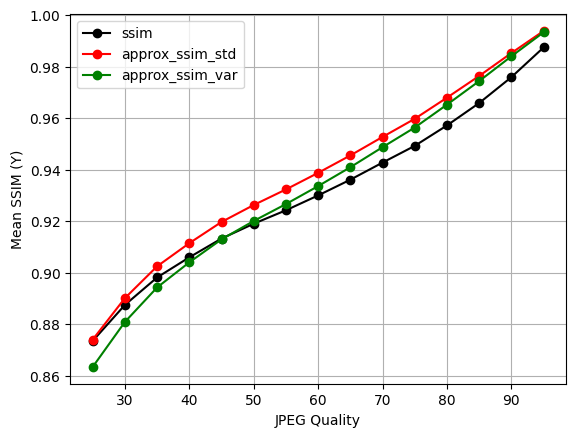

In [6]:
mean_results = (
    results
    .groupby("quality", as_index=False)[["ssim", "approx_ssim_std", "approx_ssim_var"]]
    .mean()
    .sort_values("quality")
)

REPORT_COLORS = {
    "ssim": "#000000",           
    "approx_ssim_std": "#ff0000",
    "approx_ssim_var": "#008000",
}

mean_results.plot(
    x="quality",
    y=["ssim", "approx_ssim_std", "approx_ssim_var"],
    marker="o",
    color=[
        REPORT_COLORS["ssim"], REPORT_COLORS["approx_ssim_std"], REPORT_COLORS["approx_ssim_var"],
    ],
    xlabel="JPEG Quality",
    ylabel="Mean SSIM (Y)",
    grid=True,
);